In [111]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader 
from torchvision import transforms , datasets

In [112]:
transform = transforms.ToTensor()
train = datasets.MNIST(
    root= './data',
    train= True,
    download= True,
    transform= transform
)
test = datasets.MNIST(
     root= './data',
    train= False,
     download= True,
     transform= transform
)
train_loader = DataLoader(
    train,
    batch_size=128,
    shuffle=True
)
test_loader= DataLoader(
    test,
    batch_size=128,
    shuffle=False
)

In [113]:
images = []
labels = []
for i in range(5):
    image , label = train[i]
    images.append(image)
    labels.append(label)
images = torch.stack(images)
print(images.shape)
print(labels)

torch.Size([5, 1, 28, 28])
[5, 0, 4, 1, 9]


In [114]:

noise = torch.randn(images.shape)*0.2
noise_images = images+noise
noise_images = torch.clamp(noise_images , 0, 1)


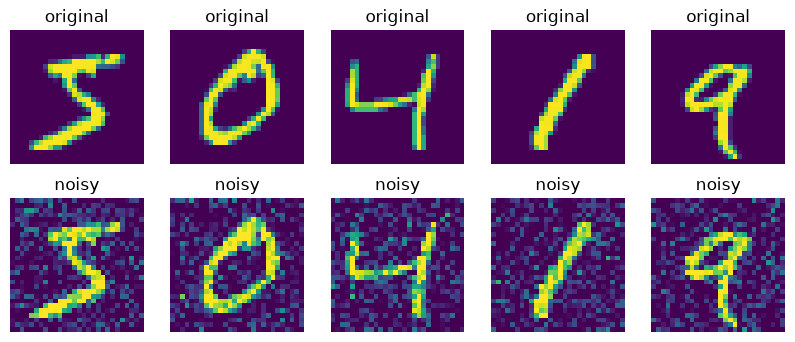

In [115]:
plt.figure(figsize=(10 , 4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze())
    plt.title('original')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(noise_images[i].squeeze())
    plt.title('noisy')
    plt.axis('off')

plt.show()

In [116]:
model = nn.Sequential(

    nn.Flatten(),

    nn.Linear(28*28 , 128),
    nn.ReLU(),
    nn.Linear(128,32),
    nn.ReLU(),

    nn.Linear(32,128),
    nn.ReLU(),
    nn.Linear(128,28*28),
    nn.Sigmoid(),

    nn.Unflatten(1 , (1, 28,28))
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=128, bias=True)
  (6): ReLU()
  (7): Linear(in_features=128, out_features=784, bias=True)
  (8): Sigmoid()
  (9): Unflatten(dim=1, unflattened_size=(1, 28, 28))
)


In [117]:
criterian = nn.MSELoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)


In [118]:
epochs = 50
for epoch in range(epochs):
    output = model(noise_images)
    loss = criterian(output , images)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


In [119]:
with torch.no_grad():
    reconstructed = model(noise_images)

reconstructed = reconstructed.reshape(5, 1 , 28, 28)

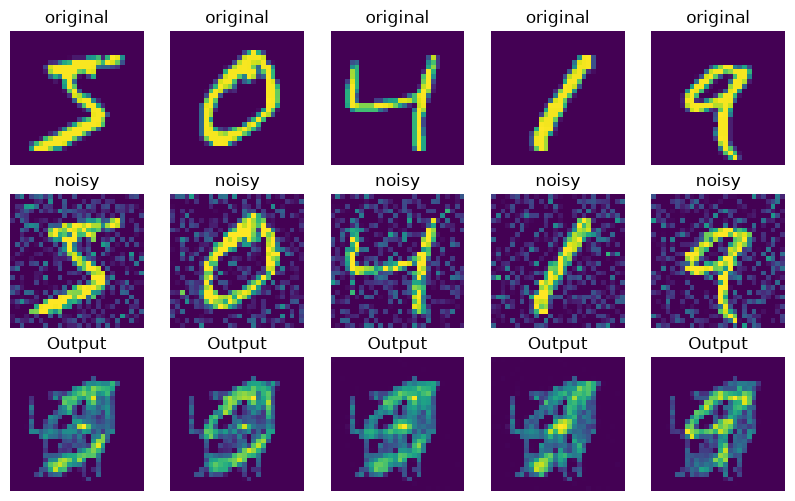

In [120]:

plt.figure(figsize=(10,6))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(images[i].squeeze())
    plt.title('original')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(noise_images[i].squeeze())
    plt.title('noisy')
    plt.axis('off')

    plt.subplot(3, 5, i+11)
    plt.imshow(reconstructed[i].squeeze())
    plt.title("Output")
    plt.axis('off')

plt.show()